In [31]:
import os
import sys
import re
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import importlib
import seaborn as sns

import catrace.exp_collection as ecl
import catrace.dimensionality_reduction as catdr
import catrace.process_time_trace as ptt 

from os.path import join as pjoin
from catrace.dataset import load_dataset_config

In [32]:
# dataset_name = 'juvenile'
# window_name = 'time_window_5s'

# dataset_name = 'juvenile_noise_std0p5'
# window_name = 'time_window_3s'
dataset_name = 'juvenile_dfovf'
window_name = 'time_window_3s'

config_file = f'../dataset_configs/{dataset_name}_dataset_t7.json'

overwrite = False


from analysis_config import juvenile_window_name_to_frames
window = juvenile_window_name_to_frames[window_name]
print(window_name, window)
window_tag = f'window_{window[0]}to{window[1]}'

import os
fig_dir = f'../../figures_for_paper/{dataset_name}/{window_name}/umap'
os.makedirs(fig_dir, exist_ok=True)

time_window_3s [38, 63]


In [33]:
dsconfig= load_dataset_config(config_file)
umap_dir = pjoin(dsconfig.processed_trace_dir, 'umap', window_tag)
os.makedirs(umap_dir, exist_ok=True)

In [34]:
from matplotlib import rcParams
rcParams['font.family'] = 'Arial'
rcParams['pdf.fonttype'] = 42  # Use TrueType fonts
rcParams['ps.fonttype'] = 42
rcParams['ps.useafm'] = True
rcParams['axes.linewidth'] = 0.5
rcParams['xtick.major.width'] = 0.5
rcParams['ytick.major.width'] = 0.5
rcParams['savefig.dpi'] = 300  # Ensure a high resolution

In [35]:

exp_list = dsconfig.exp_list
trace_dir = dsconfig.processed_trace_dir

In [36]:
# Load aligned aligned latents
import pickle
aligned_latents = {}
for cond in dsconfig.conditions:
    latents_path = pjoin(umap_dir, f'aligned_latents_{cond}.pkl')
    with open(latents_path, 'rb') as f:
        aligned_latents[cond] = pickle.load(f)

aligned_latent_df = pd.concat(aligned_latents, axis=1, keys=aligned_latents.keys())
aligned_latent_df.columns.names = ['condition', 'latent_dim']


In [37]:
# Plot the four conditions
def plot_conds(df, plot_func, sharex=False,
               sharey=False, figsize=None, ncol=4, *args, **kwargs):
    nrow = 1
    if figsize is None:
        figsize=[4*ncol, 3.5*nrow]
    fig, axes = plt.subplots(nrow, ncol, sharex=sharex,
                             sharey=sharey, figsize=figsize)
    for idx, (name, group) in enumerate(df.groupby(level='condition', axis=1, sort=False)):
        ax = axes.flatten()[idx]
        plot_func(group, *args, **kwargs, ax=ax)
        ax.set_title(name, fontsize=24)

    for ax in axes.flatten():
        ax.tick_params(axis='both', labelsize=20)
    plt.tight_layout()
    return fig, axes

C:\Users\hubob\AppData\Local\Temp\ipykernel_7580\3199819127.py:9: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  for idx, (name, group) in enumerate(df.groupby(level='condition', axis=1, sort=False)):
C:\Users\hubob\Projects\Dp_manifold_rest\catrace\catrace\dimensionality_reduction.py:385: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = embeddf.groupby(level=manifold_level)


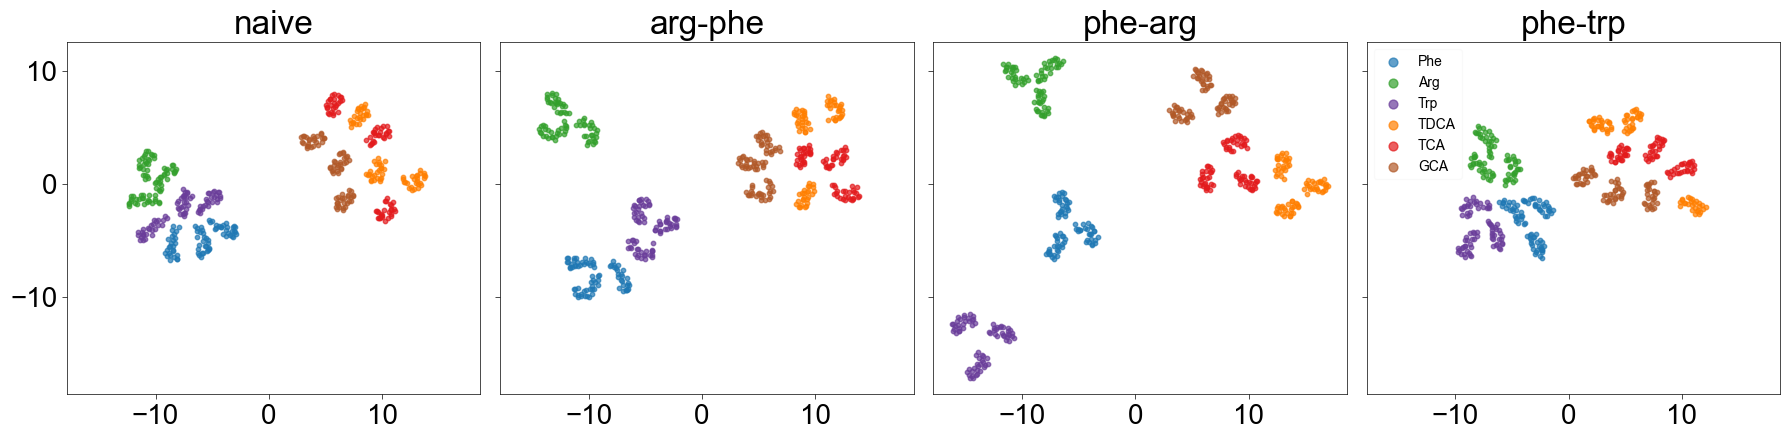

In [38]:
import catrace.visualize as catvis
importlib.reload(catdr)
component_idx = (0, 1)
clr_cycle = ['#1f78b4', '#33a02c', '#6a3d9a', '#ff7f00', '#e31a1c', '#b15928']
markers = ['o'] * 6
col_idxs = aligned_latent_df.columns.get_level_values('condition').isin(['naive', 'arg-phe', 'phe-arg', 'phe-trp'])
sub_aligned_latent_df = aligned_latent_df.loc[:, col_idxs]
fig, axes = plot_conds(sub_aligned_latent_df, catdr.plot_embed_2d, sharex=True, sharey=True, component_idx=component_idx, manifold_level='odor',
                       clr_cycle=clr_cycle,
                       figsize=(9*2,4.5),
                       ncol=4,
                       markers=markers, marker_size=10,
                       plot_type='scatter')
ax = axes[-1]
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::3], labels[::3], framealpha=0.1, markerscale=2)
plt.tight_layout()
#fig.savefig(pjoin(dsconfig.fig_dir, f'{ensemble_name}_umap_aligned_2d.pdf'))

# Get the x and y lim of the plot
xlims = ax.get_xlim()
ylims = ax.get_ylim()

# Save figure
from catrace.for_paper import save_figure_for_paper
save_figure_for_paper(fig, 'umap_aligned', fig_dir)

In [39]:
sub_aligned_latent_df_frame = sub_aligned_latent_df.copy()
# Rename the last level of the multiindex row to 'frame'
sub_aligned_latent_df_frame.index = sub_aligned_latent_df_frame.index.set_names('frame', level=-1)

In [40]:
# Save result data to CSV
figure_data_dir = os.path.join('../../publish_dataset/Hu_Temiz_et_al_dataset', 'figure_data')
os.makedirs(figure_data_dir, exist_ok=True)
save_dir = os.path.join(figure_data_dir, 'extended_figure10')
os.makedirs(save_dir, exist_ok=True)


if dataset_name == 'juvenile' and window_name == 'time_window_5s':
    subpanel = 'a'
elif dataset_name == 'juvenile_noise_std0p5' and window_name == 'time_window_3s':
    subpanel = 'b'
elif dataset_name == 'juvenile_dfovf' and window_name == 'time_window_3s':
    subpanel = 'c'
else:
    subpanel = 'unknown'
sub_aligned_latent_df_frame.to_csv(os.path.join(save_dir, f'extended_figure10{subpanel}_umap.csv'))


if subpanel =='a':
    save_dir_2 = os.path.join(figure_data_dir, 'figure02')
    os.makedirs(save_dir_2, exist_ok=True)
    sub_aligned_latent_df_frame.to_csv(os.path.join(save_dir_2, f'figure02d_umap.csv'))